In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import lifelines

In [3]:
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
print(df_deaths.head(10))
print(df_deaths.shape)
print(df_deaths.dtypes)

print(df_deaths['Age'].unique()[-5:])

df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)

print(df_deaths.dtypes)
print(df_deaths['Age'].max())

   Year Age   Female     Male    Total
0  1921   0  3842.31  5124.54  8966.85
1  1921   1   719.25   890.36  1609.61
2  1921   2   330.11   358.94   689.05
3  1921   3   166.06   249.66   415.72
4  1921   4   190.07   196.52   386.59
5  1921   5   149.05   153.40   302.45
6  1921   6   150.05   137.36   287.41
7  1921   7   109.04   118.31   227.35
8  1921   8    81.03   114.30   195.33
9  1921   9    78.03    82.22   160.25
(11211, 5)
Year        int64
Age        object
Female    float64
Male      float64
Total     float64
dtype: object
['106' '107' '108' '109' '110+']
Year        int64
Age         int64
Female    float64
Male      float64
Total     float64
dtype: object
110


In [4]:
df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)
print(df_exposure.head())

   Year  Age    Female      Male      Total
0  1921    0  64052.13  66958.13  131010.26
1  1921    1  59619.24  62092.83  121712.08
2  1921    2  57126.01  59355.89  116481.90
3  1921    3  57483.85  59481.99  116965.84
4  1921    4  58407.04  60384.61  118791.65


In [5]:
df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))

#calculation of mortality rates
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df['mx_male'] = df['Male_deaths'] / df['Male_exp']
df['mx_female'] = df['Female_deaths'] / df['Female_exp']

print(df.head())
print(df.shape)

   Year  Age  Female_deaths  Male_deaths  Total_deaths  Female_exp  Male_exp  \
0  1921    0        3842.31      5124.54       8966.85    64052.13  66958.13   
1  1921    1         719.25       890.36       1609.61    59619.24  62092.83   
2  1921    2         330.11       358.94        689.05    57126.01  59355.89   
3  1921    3         166.06       249.66        415.72    57483.85  59481.99   
4  1921    4         190.07       196.52        386.59    58407.04  60384.61   

   Total_exp  mx_total   mx_male  mx_female  
0  131010.26  0.068444  0.076533   0.059987  
1  121712.08  0.013225  0.014339   0.012064  
2  116481.90  0.005916  0.006047   0.005779  
3  116965.84  0.003554  0.004197   0.002889  
4  118791.65  0.003254  0.003254   0.003254  
(11211, 11)


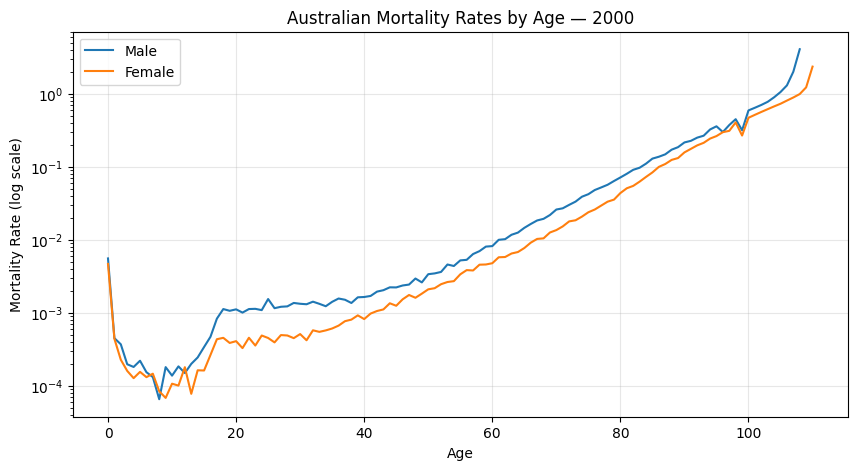

In [6]:
year = 2000
subset = df[df['Year'] == year]

# Mortality rate by Age. Log scale to visualise the range of rates
plt.figure(figsize=(10, 5))
plt.plot(subset['Age'], subset['mx_male'], label='Male')
plt.plot(subset['Age'], subset['mx_female'], label='Female')
plt.yscale('log')
plt.xlabel('Age')
plt.ylabel('Mortality Rate (log scale)')
plt.title(f'Australian Mortality Rates by Age — {year}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

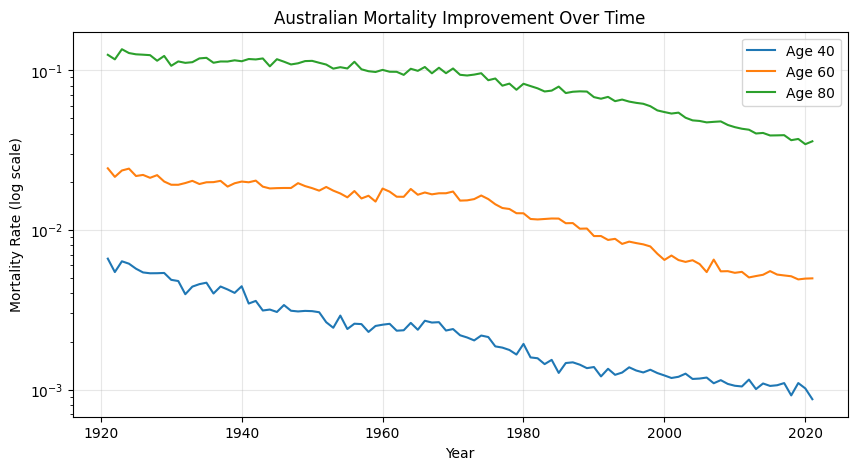

In [7]:
ages_to_track = [40, 60, 80]
years = sorted(df['Year'].unique())

# second plot, mortality improvement over time for selected ages
plt.figure(figsize=(10, 5))
for age in ages_to_track:
    subset = df[df['Age'] == age]
    plt.plot(subset['Year'], subset['mx_total'], label=f'Age {age}')

plt.xlabel('Year')
plt.ylabel('Mortality Rate (log scale)')
plt.yscale('log')
plt.title('Australian Mortality Improvement Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\dongg\UNSW\MLProj\ML-vs-Actuarial-Methods-Mortality\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


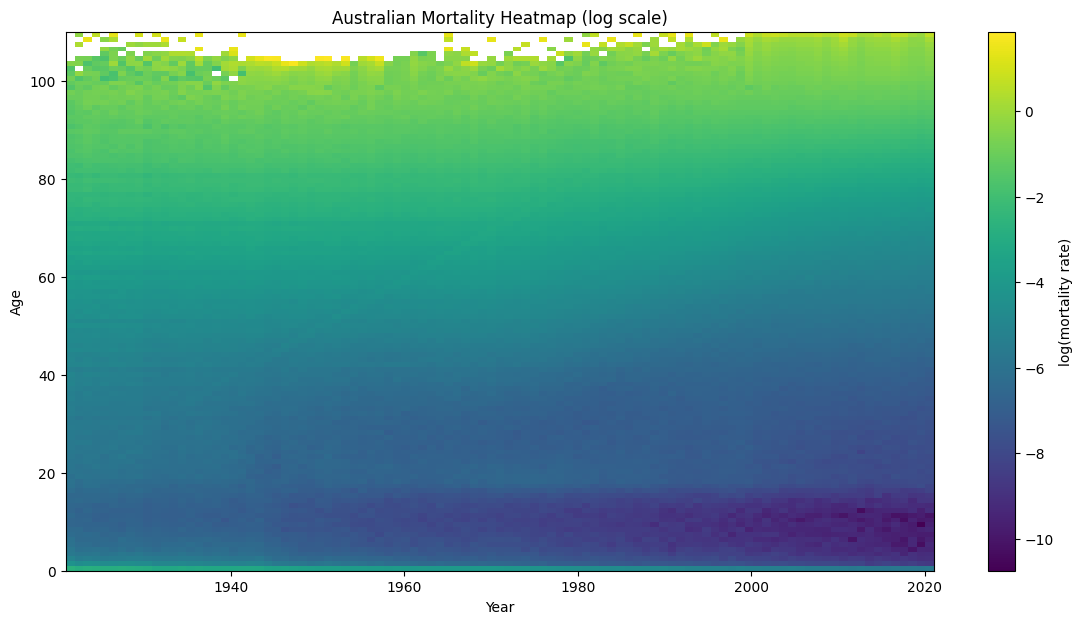

In [8]:
import numpy as np

# A heatmap of mortality rates by Age and Year
pivot = df.pivot(index='Age', columns='Year', values='mx_total')

plt.figure(figsize=(14, 7))
plt.imshow(np.log(pivot), aspect='auto', origin='lower',
           extent=[df['Year'].min(), df['Year'].max(), 0, 110])
plt.colorbar(label='log(mortality rate)')
plt.xlabel('Year')
plt.ylabel('Age')
plt.title('Australian Mortality Heatmap (log scale)')
plt.show()